# 03 - Sparse Autoencoder Training & Semantic Grounding

## 1. Setup and Imports
Configure paths to seamlessly run on Colab or locally, and install required libraries.

In [2]:
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    base_dir = '/content/drive/MyDrive/xai-project5'
else:
    base_dir = os.path.abspath(os.path.join('..', '..'))

feat_dir = os.path.join(base_dir, 'src', 'results', '01_feature_extraction')
dict_dir = os.path.join(base_dir, 'src', 'results', '02_dictionary_creation')
save_dir = os.path.join(base_dir, 'src', 'results', '03_sae_training')
scripts_path = os.path.join(base_dir, 'src', 'scripts')
req_path = os.path.join(base_dir, 'requirements.txt')

os.makedirs(save_dir, exist_ok=True)

if scripts_path not in sys.path:
    sys.path.append(scripts_path)

print(f"Setup complete.\nOutput directory: {save_dir}")


Setup complete.
Output directory: /Users/riccardo/Library/CloudStorage/GoogleDrive-riccardomarconi01@gmail.com/Il mio Drive/Progetti/04 - Explainable and Trustworthy AI/Project/xai-project5/src/results/03_sae_training


In [2]:
!pip install -q -r "{req_path}"


In [3]:
import torch
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from transformers import AutoProcessor, AutoModel
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import random_split
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sae import SparseAutoencoder, sae_loss_function

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


## 2. Sparse Autoencoder Training

**Sparse Autoencoders (SAEs)** implement a form of *sparse dictionary learning*, aiming to learn a sparse decomposition of a signal into an overcomplete dictionary of atoms.

Given an embedding $v \in \mathbb{R}^d$, the SAE decomposes the vector into:
- **Activation vector**: $\phi(v) := \sigma(W_{enc}^{\top}(v - b))$
- **Reconstructed vector**: $\hat{v} := W_{dec}^{\top}\phi(v) + b$

The loss function combines a **reconstruction objective** with a **sparsity regularization**:
$$\mathcal{L}(v) = R(v) + \lambda S(v)$$
where $R(v) = \|v - \hat{v}\|_2^2$ (L2 Loss) and $S(v) = \|\phi(v)\|_1$ (L1 Loss).

In [4]:
embeddings_path = os.path.join(feat_dir, 'biomedclip_openi_with_reports.pt')
print(f"Caricamento dataset visivo da: {embeddings_path}")

# Carichiamo il file .pt
data = torch.load(embeddings_path, map_location=device)

# Estraiamo il tensore puro dal dizionario salvato nel Notebook 1
if isinstance(data, dict) and 'embeddings' in data:
    vision_embeddings = data['embeddings']
else:
    vision_embeddings = data # Fallback se è già un tensore

# Assicuriamoci che i dati siano in formato float32
vision_embeddings = vision_embeddings.to(torch.float32)

dataset = TensorDataset(vision_embeddings)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

SEED = 42
split_generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(
    dataset, 
    [train_size, val_size], 
    generator=split_generator
)

BATCH_SIZE = 256
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training info: {len(train_dataset)} samples")
print(f"Validation info: {len(val_dataset)} samples")

Caricamento dataset visivo da: /Users/riccardo/Library/CloudStorage/GoogleDrive-riccardomarconi01@gmail.com/Il mio Drive/Progetti/04 - Explainable and Trustworthy AI/Project/xai-project5/src/results/01_feature_extraction/biomedclip_openi_with_reports.pt
Training info: 2932 samples
Validation info: 734 samples


In [5]:
INPUT_DIM = vision_embeddings.shape[1]
HIDDEN_DIM = 1024
LR = 1e-3
L1_LAMBDA = 1e-3
EPOCHS = 300

sae = SparseAutoencoder(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM).to(device)
optimizer = optim.Adam(sae.parameters(), lr=LR)
# We cut the LR by half (factor=0.5) if the loss doesn't improve for 10 epochs
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
print(f"SAE inizializzato con successo!")

SAE inizializzato con successo!


In [ ]:
# The model is saved as: sae_model_final_e{EPOCHS}_l{L1_LAMBA}_h{HIDDEN_DIM}
model_name = f'e{EPOCHS}_l{L1_LAMBDA}_h{HIDDEN_DIM}'

checkpoint_path = os.path.join(save_dir, f'sae_checkpoint_{model_name}.pt')
final_model_path = os.path.join(save_dir, f'sae_model_final_{model_name}.pt')

start_epoch = 0
history = {'total': [], 'mse': [], 'l1': [], 'lr': [], 'val_total': []}

RESUME_TRAINING = False

# Resume from checkpoint if interrupted
if RESUME_TRAINING and os.path.exists(checkpoint_path):
    print("Found training checkpoint! Resuming...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    sae.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    history = checkpoint['history']
    if 'lr' not in history:
        history['lr'] = []
    if 'val_total' not in history:
        history['val_total'] = []
    
    print(f"Resuming from epoch {start_epoch + 1}...")
else:
    print("Starting a new training")

print("\n--- STARTING SAE TRAINING ---")
for epoch in range(start_epoch, EPOCHS):
    ### --- Train phase ---
    sae.train()

    epoch_total_loss = 0.0
    epoch_mse_loss = 0.0
    epoch_l1_loss = 0.0

    for batch in train_dataloader:
        x = batch[0].to(device)
        
        # Forward pass
        x_hat, z = sae(x)
        
        # Calculate loss
        total_loss, mse_loss, l1_loss = sae_loss_function(x, x_hat, z, L1_LAMBDA)
        
        # Backward and optimize
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        # Normalize decoder weights to prevent collapse (force norm=1)
        sae.normalize_decoder_weights()

        epoch_total_loss += total_loss.item()
        epoch_mse_loss += mse_loss.item()
        epoch_l1_loss += l1_loss.item()
    
    avg_total_loss = epoch_total_loss / len(train_dataloader)
    avg_mse = epoch_mse_loss / len(train_dataloader)
    avg_l1 = epoch_l1_loss / len(train_dataloader)

    ### --- Validation Phase ---
    sae.eval()

    val_total_loss = 0.0

    with torch.no_grad():
        for batch in val_dataloader:
            x = batch[0].to(device)
            x_hat, z = sae(x)
            
            loss, _, _ = sae_loss_function(x, x_hat, z, L1_LAMBDA)
            val_total_loss += loss.item()
            
    avg_val_loss = val_total_loss / len(val_dataloader)
    
    # Step the scheduler based on the average total loss
    scheduler.step(avg_val_loss)
    
    current_lr = optimizer.param_groups[0]['lr']

    history['total'].append(avg_total_loss)
    history['mse'].append(avg_mse)
    history['l1'].append(avg_l1)
    history['lr'].append(current_lr)
    history['val_total'].append(avg_val_loss)

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | "
          f"LR: {current_lr:.2e} | "
          f"Train Loss: {avg_total_loss:.4e} | "
          f"Val Loss: {avg_val_loss:.4e} | "
          f"MSE: {avg_mse:.4e} | "
          f"L1: {avg_l1:.4e}")
          
    # Save checkpoint at the end of each epoch
    torch.save({
        'epoch': epoch,
        'model_state_dict': sae.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'history': history
    }, checkpoint_path)

# Save final model properly for Notebook 04
torch.save(sae.state_dict(), final_model_path)
print(f"\nTraining complete! Final model saved to: {final_model_path}")

Starting a new training

--- STARTING SAE TRAINING ---
Epoch [01/300] | LR: 1.00e-03 | Train Loss: 6.4886e-04 | Val Loss: 2.5472e-04 | MSE: 6.3839e-04 | L1: 1.0470e-02
Epoch [02/300] | LR: 1.00e-03 | Train Loss: 2.1012e-04 | Val Loss: 1.7580e-04 | MSE: 2.0285e-04 | L1: 7.2724e-03
Epoch [03/300] | LR: 1.00e-03 | Train Loss: 1.5206e-04 | Val Loss: 1.3156e-04 | MSE: 1.4531e-04 | L1: 6.7512e-03
Epoch [04/300] | LR: 1.00e-03 | Train Loss: 1.1403e-04 | Val Loss: 9.9647e-05 | MSE: 1.0706e-04 | L1: 6.9728e-03
Epoch [05/300] | LR: 1.00e-03 | Train Loss: 8.7819e-05 | Val Loss: 7.9762e-05 | MSE: 8.0515e-05 | L1: 7.3043e-03
Epoch [06/300] | LR: 1.00e-03 | Train Loss: 7.2253e-05 | Val Loss: 6.7636e-05 | MSE: 6.4658e-05 | L1: 7.5946e-03
Epoch [07/300] | LR: 1.00e-03 | Train Loss: 6.2431e-05 | Val Loss: 5.9515e-05 | MSE: 5.4677e-05 | L1: 7.7540e-03
Epoch [08/300] | LR: 1.00e-03 | Train Loss: 5.5442e-05 | Val Loss: 5.3631e-05 | MSE: 4.7614e-05 | L1: 7.8281e-03
Epoch [09/300] | LR: 1.00e-03 | Train Los

## 3. Training Data Analysis
Let's visualize the training metrics to ensure the SAE converged properly and correctly balanced the trade-off between Reconstruction (MSE) and Sparsity (L1).

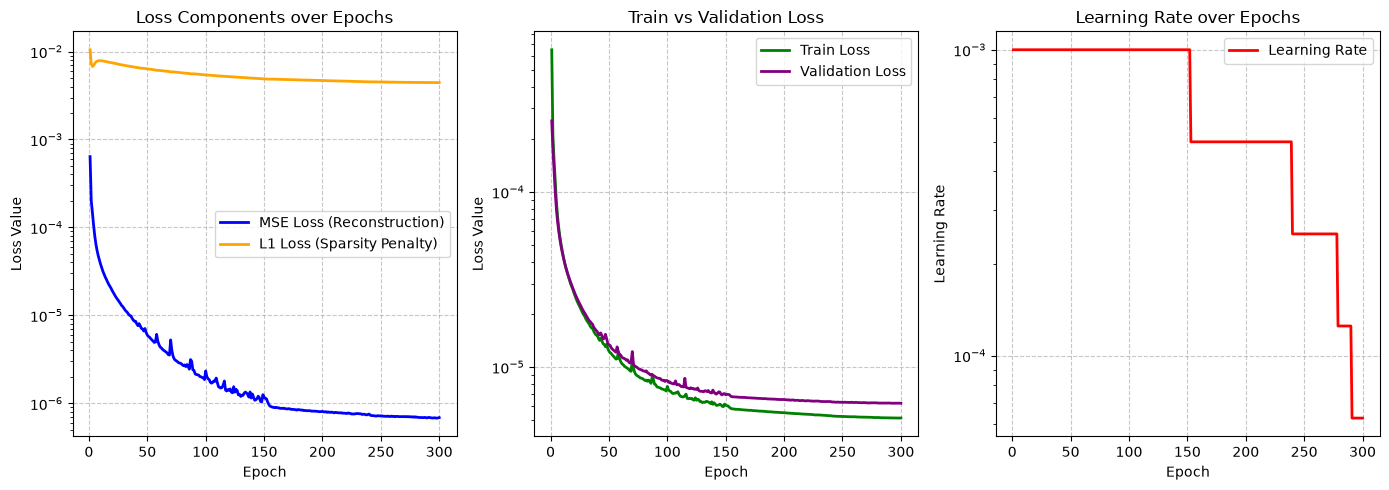

In [17]:
epochs_range = range(1, len(history['total']) + 1)

plt.figure(figsize=(14, 5))

# Plot 1: Reconstruction vs Sparsity Loss
plt.subplot(1, 3, 1)
plt.plot(epochs_range, history['mse'], label='MSE Loss (Reconstruction)', color='blue', linewidth=2)
plt.plot(epochs_range, history['l1'], label='L1 Loss (Sparsity Penalty)', color='orange', linewidth=2)
plt.title('Loss Components over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.yscale('log') # Log scale for better visibility if differences are huge
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Total Train vs Validation Loss
plt.subplot(1, 3, 2)
plt.plot(epochs_range, history['total'], label='Train Loss', color='green', linewidth=2)
if 'val_total' in history and len(history['val_total']) == len(epochs_range):
    plt.plot(epochs_range, history['val_total'], label='Validation Loss', color='purple', linewidth=2)
plt.title('Train vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.yscale('log') # Added log scale here too, as total loss usually drops exponentially
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Plot 3: Learning Rate
plt.subplot(1, 3, 3)
if 'lr' in history and len(history['lr']) == len(epochs_range):
    plt.plot(epochs_range, history['lr'], label='Learning Rate', color='red', linewidth=2)
plt.title('Learning Rate over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.yscale('log') 
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

## 3.5 Model Evaluation & Sparsity Check
In this section, we load the trained weights of a specific Sparse Autoencoder model to evaluate its performance on an unseen validation batch. 

We assess two primary metrics:
1. **Reconstruction Quality**: Measured via Mean Squared Error (MSE) and Cosine Similarity, this tells us how accurately the SAE can reconstruct the original image embeddings.
2. **Sparsity (L0 Norm)**: We calculate the average number of active (non-zero) hidden features per embedding. This tells us how effectively the model has compressed the dense representation into a sparse, interpretable format.


In [10]:
INPUT_DIM = vision_embeddings.shape[1]
HIDDEN_DIM = 2048
sae = SparseAutoencoder(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM).to(device)

selected_model = 'sae_model_final_e20_l0.0001_h2048.pt' 
weights_path = os.path.join(save_dir, selected_model)
print(f"\nAttempting to load weights from: {weights_path}")

try:
    checkpoint = torch.load(weights_path, map_location=device)
    
    # Check if the file is a full checkpoint dictionary (with optimizer state) or just the raw model weights
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        sae.load_state_dict(checkpoint['model_state_dict'])
        print("\nFull checkpoint detected. Model weights loaded successfully!")
    else:
        sae.load_state_dict(checkpoint)
        print("\nRaw model weights loaded successfully!")
except Exception as e:
    print(f"\nError loading weights: {e}")

# Put the model in evaluation mode
sae.eval()

# Get a single batch from the validation dataloader
x_batch = next(iter(val_dataloader))[0].to(device)

with torch.no_grad():
    # Forward pass through the SAE
    x_hat, z = sae(x_batch)
    
    # Calculate Average L0 Sparsity (how many features are active per embedding)
    active_features_per_sample = (z > 0).sum(dim=1).float()
    avg_active_features = active_features_per_sample.mean().item()
    
    # Calculate Reconstruction Quality (Cosine Similarity)
    cos_sim = F.cosine_similarity(x_batch, x_hat, dim=1)
    avg_cos_sim = cos_sim.mean().item()
    
    # Mean Squared Error (MSE)
    mse = F.mse_loss(x_hat, x_batch).item()

hidden_dim = sae.encoder.out_features

print("\n--- SAE Evaluation on a Validation Batch ---")
print(f"Batch size evaluated: {x_batch.shape[0]}")
print(f"SAE hidden dimensions: {hidden_dim}")
print(f"Average Active Features (L0): {avg_active_features:.1f} out of {hidden_dim}")
print(f"Average Cosine Similarity:    {avg_cos_sim:.4f} (1.0000 is perfect)")
print(f"Mean Squared Error:           {mse:.4e} (0.0000 is perfect)")


Attempting to load weights from: /Users/riccardo/Library/CloudStorage/GoogleDrive-riccardomarconi01@gmail.com/Il mio Drive/Progetti/04 - Explainable and Trustworthy AI/Project/xai-project5/src/results/03_sae_training/sae_model_final_e20_l0.0001_h2048.pt

Raw model weights loaded successfully!

--- SAE Evaluation on a Validation Batch ---
Batch size evaluated: 256
SAE hidden dimensions: 2048
Average Active Features (L0): 333.2 out of 2048
Average Cosine Similarity:    0.9960 (1.0000 is perfect)
Mean Squared Error:           1.5511e-05 (0.0000 is perfect)


#### Model Results:
- sae_model_final_e300_l0.001_h1024: \
    SAE hidden dimensions: 1024 \
    Average Active Features (L0): 262.8 out of 1024 \
    Average Cosine Similarity:    0.9996 (1.0000 is perfect) \
    Mean Squared Error:           1.6922e-06 (0.0000 is perfect)

- sae_model_final_e300_l0.0001_h1024: \
    SAE hidden dimensions: 1024 \
    Average Active Features (L0): 322.2 out of 1024 \
    Average Cosine Similarity:    0.9999 (1.0000 is perfect) \
    Mean Squared Error:           4.0014e-07 (0.0000 is perfect)

- sae_model_final_e20_l0.0001_h2048: \
    SAE hidden dimensions: 2048 \
    Average Active Features (L0): 333.2 out of 2048 \
    Average Cosine Similarity:    0.9960 (1.0000 is perfect) \
    Mean Squared Error:           1.5511e-05 (0.0000 is perfect)

## 4. Global Explainability: Semantic Grounding

Global explainability aims to map and understand the model's internal architecture in its entirety, independently of individual input samples. In this paradigm, the goal is to build a dictionary that connects the latent visual concepts—learned in a totally unsupervised manner—to human language.

This process, known as *semantic grounding*, is achieved by computing the cosine similarity between the textual embeddings of known clinical concepts (from Notebook 02) and the decoder dictionary learned by the Sparse Autoencoder.

Since both vectors are subjected to L2 normalization, calculating the cosine similarity elegantly reduces to a single matrix multiplication: $S = T \cdot W_{dec}$, where $T$ represents the text embeddings matrix and $W_{dec}$ is the SAE decoder dictionary. This geometric operation allows us to establish the "at-rest" alignment of the network, assigning the most strongly connected latent neuron to each medical phrase.

In [12]:
dict_path = os.path.join(dict_dir, 'biomedclip_medical_dictionary_embeddings.pt')
print(f"Loading Medical Dictionary from: {dict_path}")

dictionary_data = torch.load(dict_path, map_location=device)
medical_concepts = list(dictionary_data.keys())
tensors_list = list(dictionary_data.values())

# Concateniamo i tensori in una singola matrice T
T_matrix = torch.stack(tensors_list).to(device)

# Rimuoviamo eventuali dimensioni extra (se la shape è [N, 1, 512] la facciamo diventare [N, 512])
if T_matrix.dim() == 3:
    T_matrix = T_matrix.squeeze(1)

print(f"Caricati {len(medical_concepts)} concetti clinici semantici.")
print(f"Shape della Matrice T: {T_matrix.shape}")

# Define the SAE and load the specific weights we want to evaluate
eval_model_path = os.path.join(save_dir, 'sae_model_final_e300_l0.001_h1024.pt')
print(f"Loading SAE weights from: {eval_model_path}")

INPUT_DIM = vision_embeddings.shape[1]
HIDDEN_DIM = 1024
sae = SparseAutoencoder(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM).to(device)
sae.load_state_dict(torch.load(eval_model_path, map_location=device))
sae.eval() # Put the model in evaluation mode

# Compute Cosine Similarity
with torch.no_grad():
    sae_dictionary = F.normalize(sae.decoder.weight.data, p=2, dim=0)

similarities = torch.matmul(T_matrix, sae_dictionary)

top_k = 10
# We'll print just a sample (first 5 concepts) to avoid cluttering the output
sample_size = min(5, len(medical_concepts))
print(f"\nShowing Grounding for the first {sample_size} concepts:\n")

for idx in range(sample_size):
    concept = medical_concepts[idx]
    concept_sims = similarities[idx]
    
    # Get top K values and their indices (the SAE "neurons")
    top_values, top_indices = torch.topk(concept_sims, top_k)
    
    print(f"Textual Concept: '{concept}'")
    for i in range(top_k):
        print(f"  -> SAE Neuron {top_indices[i].item():4d} (Similarity: {top_values[i].item():.4f})")
    print("-" * 40)


Loading Medical Dictionary from: /Users/riccardo/Library/CloudStorage/GoogleDrive-riccardomarconi01@gmail.com/Il mio Drive/Progetti/04 - Explainable and Trustworthy AI/Project/xai-project5/src/results/02_dictionary_creation/biomedclip_medical_dictionary_embeddings.pt
Caricati 14 concetti clinici semantici.
Shape della Matrice T: torch.Size([14, 512])
Loading SAE weights from: /Users/riccardo/Library/CloudStorage/GoogleDrive-riccardomarconi01@gmail.com/Il mio Drive/Progetti/04 - Explainable and Trustworthy AI/Project/xai-project5/src/results/03_sae_training/sae_model_final_e300_l0.001_h1024.pt

Showing Grounding for the first 5 concepts:

Textual Concept: 'abdomen'
  -> SAE Neuron   58 (Similarity: 0.2235)
  -> SAE Neuron  613 (Similarity: 0.2109)
  -> SAE Neuron  466 (Similarity: 0.2043)
  -> SAE Neuron  534 (Similarity: 0.1993)
  -> SAE Neuron  908 (Similarity: 0.1975)
  -> SAE Neuron  342 (Similarity: 0.1832)
  -> SAE Neuron  594 (Similarity: 0.1829)
  -> SAE Neuron  363 (Similarity:

## 5. Local Explainability: Dissecting a Single Clinical Case

While global explainability defines the network's vocabulary, local explainability investigates its dynamic behavior when faced with a specific input sample (e.g., a single patient's chest X-ray).

### Translating Activations into Diagnosis
When a raw X-ray image is processed by BioMedCLIP and forwarded through the SAE, the network responds by firing a highly sparse activation vector $z$. 
1. The script captures the top most intensely fired neurons.
2. It queries the global similarity matrix $S$ to find the medical label closest to those active channels.
3. It outputs a human-readable explanation, pinpointing exactly what visual pathologies the AI detected in that specific image, converting abstract dimensions into transparent, clinical insights.

In [13]:
import open_clip

def explain_single_image(path, vlm_model, preprocess, sae_model, concept_similarities, concept_names, device, top_k_neurons=5):
    vlm_model.eval()
    sae_model.eval()
    
    # Using a dummy image if path doesn't exist just for demonstration purposes
    if not os.path.exists(path):
        print(f"Image not found at {path}. Using a blank dummy image to test logic.")
        import numpy as np
        image = Image.fromarray(np.zeros((224, 224, 3), dtype=np.uint8))
    else:
        image = Image.open(path)

    if image.mode != "RGB":
        image = image.convert("RGB")

    image_input = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        # Estraiamo l'embedding dell'immagine con open_clip
        vision_features = vlm_model.encode_image(image_input)
        
        # Normalizzazione L2 obbligatoria
        vision_embeddings = F.normalize(vision_features, p=2, dim=1)

        # Passaggio nel Sparse Autoencoder
        _, z = sae_model(vision_embeddings)

    activations = z[0] # Extracting the activation vector
    top_activation_values, top_neuron_indices = torch.topk(activations, top_k_neurons)

    found_concepts = False
    for val, neuron_idx in zip(top_activation_values, top_neuron_indices):
        if val.item() <= 0.05:
            continue 
            
        found_concepts = True
        print(f"\n[Neuron {neuron_idx.item():4d}] -> Activation Intensity: {val.item():.4f}")
        neuron_concept_scores = concept_similarities[:, neuron_idx]
        
        best_concept_idx = torch.argmax(neuron_concept_scores).item()
        best_concept_score = neuron_concept_scores[best_concept_idx].item()
        
        print(f"  Top Semantic Concept: '{concept_names[best_concept_idx]}'")
        print(f"  Grounding Score: {best_concept_score:.4f}")

    if not found_concepts:
        print("\nNo sufficient strong activations found for this image.")


# We load the VLM processor and model specifically for the local explanation test
print("Caricamento di BioMedCLIP per l'Explainability Locale...")
model_name = "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
vlm_model, _, preprocess = open_clip.create_model_and_transforms(model_name)
vlm_model = vlm_model.to(device)

image_test_path = os.path.join(base_dir, 'src', 'images', 'raggi_x.jpg')
print(f"\nAnalisi immagine: {image_test_path}")

explain_single_image(
    path=image_test_path, 
    vlm_model=vlm_model, 
    preprocess=preprocess, 
    sae_model=sae, 
    concept_similarities=similarities, 
    concept_names=medical_concepts, 
    device=device
)

Caricamento di BioMedCLIP per l'Explainability Locale...

Analisi immagine: /Users/riccardo/Library/CloudStorage/GoogleDrive-riccardomarconi01@gmail.com/Il mio Drive/Progetti/04 - Explainable and Trustworthy AI/Project/xai-project5/src/images/raggi_x.jpg

[Neuron  932] -> Activation Intensity: 0.1839
  Top Semantic Concept: 'bone diseases'
  Grounding Score: 0.1227

[Neuron  681] -> Activation Intensity: 0.1607
  Top Semantic Concept: 'aortic aneurysm'
  Grounding Score: 0.0706

[Neuron  906] -> Activation Intensity: 0.1427
  Top Semantic Concept: 'blister'
  Grounding Score: -0.0212

[Neuron  512] -> Activation Intensity: 0.1421
  Top Semantic Concept: 'atherosclerosis'
  Grounding Score: 0.1986

[Neuron  103] -> Activation Intensity: 0.1374
  Top Semantic Concept: 'arthritis'
  Grounding Score: 0.1566
